# 08 - Error analysis and the test set (Phase 5)

This is the last notebook with numbers in it. Here we finally open the **test set**.

We only do this once. Every choice we made until now was made by looking at the dev
set. If we now look at the test set and then change our mind, the test number stops
meaning anything.

The full reasoning is written out in the markdown cells below.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt

from ecg.data import load_split, class_names
from ecg.metrics import report, macro_f1, accuracy, confusion_matrix, per_class, majority_baseline
from ecg import plots

results = json.load(open("../results/phase5_test_results.json"))

# the predictions are kept in a small compressed file next to it, so the repo
# does not carry a megabyte of integers in json
saved = np.load("../results/phase5_test_predictions.npz", allow_pickle=False)
y_true = saved["y_true"].astype(int)
y_pred = saved["y_pred"].astype(int)
records = saved["rec_names"][saved["rec_code"]]

names = class_names("all")
print("test beats:", y_true.size)

test beats: 49685


## 1. The result

We took three models to the test set. All three were chosen before we looked.

In [2]:
print("%-24s %10s %12s %10s" % ("model", "dev mF1", "TEST mF1", "change"))
for label in ["timing only (4)", "shape + timing (254)", "shape only (250)"]:
    r = results[label]
    print("%-24s %10.4f %12.4f %+10.4f"
          % (label, r["dev_macro_f1"], r["test_macro_f1"],
             r["test_macro_f1"] - r["dev_macro_f1"]))
print()
print("floor on test: accuracy %.4f, macro-F1 %.4f"
      % (majority_baseline(y_true, 4), macro_f1(y_true, np.zeros_like(y_true), 4)))

model                       dev mF1     TEST mF1     change
timing only (4)              0.5572       0.4193    -0.1379
shape + timing (254)         0.3861       0.4794    +0.0932
shape only (250)             0.3232       0.4040    +0.0808

floor on test: accuracy 0.8904, macro-F1 0.2355


## 2. Something went wrong

Look again at that table.

**The model we chose is the worst one on the test set.** The 254 feature model, which
looked clearly worse on dev, is better on test by about 0.06.

We are **not** going to change our answer now. If we pick the winner after seeing the
test set, then the test set becomes a second dev set and we have no honest number
left. So we keep our choice, we report 0.4193, and we spend the rest of this notebook
finding out **why we were wrong**.

That is more useful than the score anyway.

## 3. What the chosen model actually does

In [3]:
print(report(y_true, y_pred, names))

 class     prec   recall       f1  support
     N    0.968    0.972    0.970    44240
     S    0.148    0.033    0.053     1837
     V    0.557    0.825    0.665     3220
     F    0.000    0.000    0.000      388

  accuracy  0.9205   (baseline 0.8904)
  macro-F1  0.4221


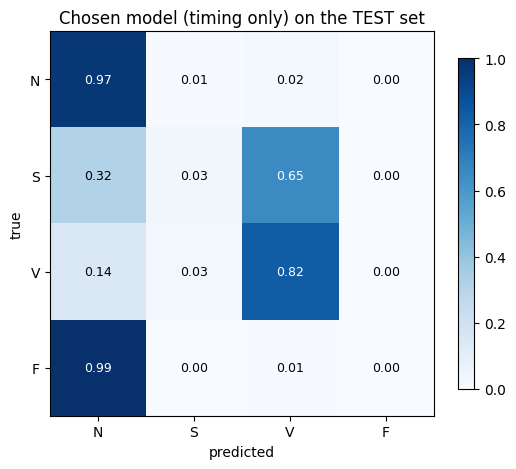

of 1837 true S beats:
   called N:   579  (31.5%)
   called S:    60  (3.3%)
   called V:  1197  (65.2%)
   called F:     1  (0.1%)


In [4]:
cm = confusion_matrix(y_true, y_pred, 4)
fig = plots.confusion(cm, names, title="Chosen model (timing only) on the TEST set")
plt.show()

print("of %d true S beats:" % cm[1].sum())
for i, n in enumerate(names):
    print("   called %s: %5d  (%.1f%%)" % (n, cm[1][i], 100 * cm[1][i] / cm[1].sum()))

**65% of all S beats were called V.**

On dev, class S had an F1 of 0.628. On test it is 0.053. Everything else stayed the
same:

| class | dev | test |
|---|---|---|
| N | 0.9737 | 0.9702 |
| **S** | **0.6280** | **0.0535** |
| V | 0.6413 | 0.6647 |
| F | 0.0000 | 0.0000 |

So the whole drop is one class.

## 4. Why: timing cannot tell S from V

Our model only sees **when** a beat arrives, not what it looks like.

The problem is that **S beats and V beats are both early**. Timing can say "this beat
came too soon". It cannot say which of the two kinds it is. For that you need the
shape.

Let us measure how well the timing feature separates S from V, on each split.

In [5]:
def auc(pos, neg):
    all_v = np.concatenate([pos, neg])
    order = all_v.argsort()
    ranks = np.empty(len(all_v)); ranks[order] = np.arange(1, len(all_v) + 1)
    a = (ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))
    return max(a, 1 - a)

print("AUC of pre_rr/local_rr, S against V.  0.5 = useless, 1.0 = perfect")
for split in ["train", "dev", "test"]:
    X, y, rec = load_split(split, features="rr", classes="all", columns=True)
    ratio = X[3]
    s, v = ratio[y.ravel() == 1], ratio[y.ravel() == 2]
    print("   %-6s S median %.3f   V median %.3f   AUC %.3f   (n_S = %d)"
          % (split, np.median(s), np.median(v), auc(s, v), len(s)))

AUC of pre_rr/local_rr, S against V.  0.5 = useless, 1.0 = perfect
   train  S median 0.784   V median 0.720   AUC 0.595   (n_S = 726)
   dev    S median 0.950   V median 0.779   AUC 0.668   (n_S = 218)
   test   S median 0.727   V median 0.726   AUC 0.514   (n_S = 1837)


On dev the feature works (0.668). On test it is **almost a coin flip (0.514)**.

Same feature, same code. Different patients.

## 5. The real mistake: our dev set had S beats from only two people

In [6]:
for split in ["dev", "test"]:
    X, y, rec = load_split(split, features="rr", classes="all", columns=True)
    ratio = X[3]
    print(split.upper() + "  (patients with 20 or more S beats)")
    rows = []
    for r in sorted(set(rec.tolist())):
        m = (rec == r) & (y.ravel() == 1)
        if m.sum() >= 20:
            rows.append((int(m.sum()), float(np.median(ratio[m])), r))
    for n, med, r in sorted(rows, reverse=True):
        print("   patient %s: %5d S beats, median ratio %.3f" % (r, n, med))
    print()

DEV  (patients with 20 or more S beats)
   patient 207:   107 S beats, median ratio 0.992
   patient 223:    73 S beats, median ratio 0.819
   patient 124:    31 S beats, median ratio 0.986



TEST  (patients with 20 or more S beats)
   patient 232:  1382 S beats, median ratio 0.738
   patient 222:   209 S beats, median ratio 0.613
   patient 202:    55 S beats, median ratio 0.558
   patient 234:    50 S beats, median ratio 0.949
   patient 100:    33 S beats, median ratio 0.763
   patient 200:    30 S beats, median ratio 0.828
   patient 213:    28 S beats, median ratio 0.777
   patient 210:    22 S beats, median ratio 0.618



Read the numbers.

In **dev**, most S beats come from patient 207, and that patient's S beats have a
ratio of **0.992**, which means they arrive almost exactly on time. So on dev the rule
"S is a bit early, V is very early" works.

In **test**, most S beats come from patient 232, and that patient's S beats have a
ratio of **0.738**. V beats sit at 0.726. They are the same.

Our model learned a rule that was true for **two people**. Dev could not tell us it
was wrong, because dev *was* those two people.

> **A dev set needs enough patients per class, not enough beats per class.**

218 S beats sounds like enough. Two S patients is not.

## 6. Looking at the mistakes

Let us plot some of the S beats that were called V, and put the average S beat and the
average V beat behind them.

In [7]:
Xw, _, _ = load_split("test", features="waveform", classes="all", columns=True)
Xw = Xw.T
Xtr, ytr, _ = load_split("train", features="waveform", classes="all", columns=True)
Xtr = Xtr.T
mean_S = Xtr[ytr.ravel() == 1].mean(axis=0)
mean_V = Xtr[ytr.ravel() == 2].mean(axis=0)

mistakes = np.where((y_true == 1) & (y_pred == 2))[0]
d_s = np.linalg.norm(Xw[mistakes] - mean_S, axis=1)
d_v = np.linalg.norm(Xw[mistakes] - mean_V, axis=1)

print("of the %d S beats called V:" % len(mistakes))
print("   %.1f%% are closer in SHAPE to the average S beat than to the average V beat"
      % (100 * (d_s < d_v).mean()))
print("   average distance to the S shape: %.2f" % d_s.mean())
print("   average distance to the V shape: %.2f" % d_v.mean())

of the 1197 S beats called V:
   94.6% are closer in SHAPE to the average S beat than to the average V beat
   average distance to the S shape: 10.40
   average distance to the V shape: 15.13


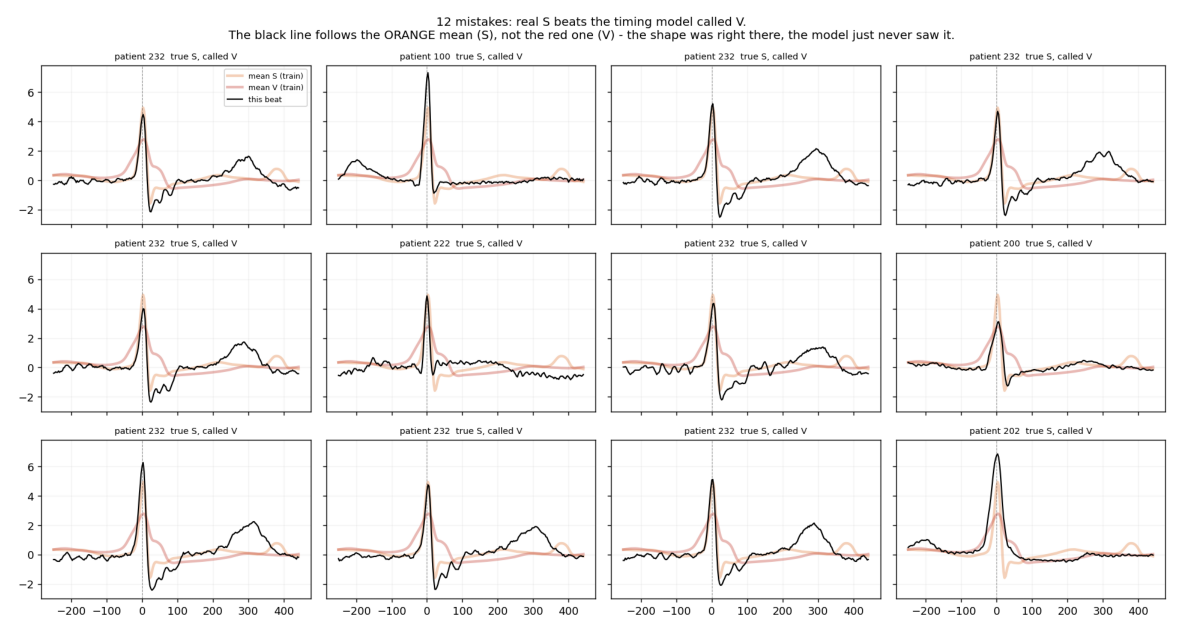

In [8]:
fig = plt.imread("../results/figures/phase5_errors.png")
plt.figure(figsize=(15, 8)); plt.imshow(fig); plt.axis("off"); plt.show()

Almost every one of them looks like an S beat: a narrow, sharp spike. The wide
rounded V shape is not there.

**The answer was in the signal. We threw it away when we chose the features.**

## 7. Bias and variance

In [9]:
print("%-24s %8s %8s %8s %12s" % ("model", "train", "dev", "TEST", "train - dev"))
for label, tr in [("timing only (4)", 0.5634),
                  ("shape + timing (254)", 0.9567),
                  ("shape only (250)", 0.9310)]:
    r = results[label]
    print("%-24s %8.4f %8.4f %8.4f %12.4f"
          % (label, tr, r["dev_macro_f1"], r["test_macro_f1"], tr - r["dev_macro_f1"]))

model                       train      dev     TEST  train - dev
timing only (4)            0.5634   0.5572   0.4193       0.0062
shape + timing (254)       0.9567   0.3861   0.4794       0.5706
shape only (250)           0.9310   0.3232   0.4040       0.6078


The two models are at **opposite ends**.

**Timing only**: train 0.5634, dev 0.5572. The gap is only 0.006, so there is almost
no variance. But it only reaches 0.56 **on the data it was trained on**. It cannot fit
even that. This is **high bias**: 4 numbers are not enough to describe the problem.
More data will not help. More regularisation will not help.

**254 features**: train 0.9567, dev 0.3861. A gap of 0.57. It learns the 17 training
patients almost perfectly and then fails on new people. This is **high variance**. The
cure is more data, and here that means **more patients**, not more beats.

In Phase 4 we ran 174 experiments on regularisation and optimisers. We were tuning the
**high bias** model, where none of those tools do anything. That is exactly what we
saw: nothing moved the score by more than 0.05.

## 8. Per patient

In [10]:
pp = results["_per_patient"]
vals = np.array(list(pp.values()))
print("macro-F1 for each of the 22 test patients:")
print("   min %.3f   median %.3f   max %.3f" % (vals.min(), np.median(vals), vals.max()))
print()
for r, v in sorted(pp.items(), key=lambda kv: kv[1]):
    bar = "#" * int(v * 40)
    print("   %s  %.3f  %s" % (r, v, bar))

macro-F1 for each of the 22 test patients:
   min 0.263   median 0.528   max 1.000

   219  0.263  ##########
   232  0.312  ############
   213  0.320  ############
   202  0.320  ############
   100  0.352  ##############
   231  0.369  ##############
   210  0.381  ###############
   200  0.465  ##################
   233  0.480  ###################
   117  0.500  ###################
   103  0.500  ###################
   121  0.556  ######################
   222  0.594  #######################
   123  0.634  #########################
   228  0.652  ##########################
   214  0.664  ##########################
   234  0.746  #############################
   111  0.833  #################################
   221  0.867  ##################################
   113  0.896  ###################################
   212  1.000  #######################################
   105  1.000  ########################################


One number hides a lot. Patients 212 and 105 get 1.000, but that is because almost all
of their beats are normal, so there is nothing to get wrong. Patient 232, who has 75%
of all the S beats in the test set, gets 0.312.

If this were a real medical tool, the **worst** patient would matter more than the
average one.

## 9. What we learned

1. **Our dev set chose the wrong model.** Not by a small amount, and not by bad luck.
2. **The reason was patients, not beats.** Dev had 218 S beats but only two people who
   really had S beats.
3. **The fix comes first, before anything else.** Choose the dev split by patients per
   class, or rotate the patients (cross validation).
4. **We tuned the wrong model.** All the Phase 4 work went into a high bias model.
5. **The shape of the beat carries the answer**, and a flat network on raw samples
   cannot read it. That is an architecture problem, and it points straight at Course 4.